<div style="background: linear-gradient(135deg, #1B5E20, #2E7D32); padding: 32px; border-radius: 14px; color: white; font-family: Arial, sans-serif;">
  <h1 style="margin:0 0 8px 0; font-size:2em;">🍎 Fruit Quality Classification</h1>
  <h2 style="margin:0 0 14px 0; font-weight:400; opacity:0.9; font-size:1.2em;">Notebook 1 — Chuẩn bị & Tổ chức lại Dataset</h2>
  <hr style="border-color:rgba(255,255,255,0.3); margin:12px 0"/>
  <p style="margin:3px 0;">📦 <b>Nguồn:</b> Kaggle — Fruit Quality Classification Dataset</p>
  <p style="margin:3px 0;">🍌 <b>Loại trái cây:</b> Apple · Banana · Guava · Lime · Orange</p>
  <p style="margin:3px 0;">⭐ <b>Chất lượng:</b> Good · Bad · Mixed</p>
  <p style="margin:3px 0;">🎯 <b>Nhãn đầu ra:</b> Apple_Good · Banana_Bad · Orange_Mixed · ... (15 lớp)</p>
</div>

---

## 📋 Mục tiêu notebook này

Chuyển đổi cấu trúc Kaggle gốc:
```
data/
├── Bad Quality_Fruits/
│   ├── Apple_Bad/
│   ├── Banana_Bad/ ...
├── Good Quality_Fruits/
│   ├── Apple_Good/ ...
└── Mixed Qualit_Fruits/
    ├── Apple_Mixed/ ...
```

Thành cấu trúc chuẩn train/valid/test:
```
dataset/
├── train/   (70%)
│   ├── Apple_Bad/
│   ├── Apple_Good/
│   ├── Apple_Mixed/ ...
├── valid/   (15%)
│   └── ...
└── test/    (15%)
    └── ...
```

**Lưu ý:** Lemon_Mixed trong dataset gốc → đổi thành Lime_Mixed để nhất quán.

## Ô 0 — Import & Cài đặt

In [1]:
import os, glob, shutil, random
from collections import defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2

# Try to import tqdm.notebook first (for Jupyter), fallback to regular tqdm
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print('✅ Import thành công!')

✅ Import thành công!


## Ô 1 — Cấu hình đường dẫn

In [2]:
# ════════════════════════════════════════════════════════════
# ⚙️  CHỈNH SỬA ĐÂY — trỏ đến thư mục dataset Kaggle của bạn
# ════════════════════════════════════════════════════════════

# Thư mục chứa dataset Kaggle gốc (có 3 subfolder: Bad/Good/Mixed)
KAGGLE_ROOT = './data'          # ← đổi thành đường dẫn thực tế

# Thư mục đích (sẽ được tạo tự động)
DATASET_DIR = './dataset'       # train/ valid/ test/ sẽ nằm ở đây

# Tỷ lệ phân chia
TRAIN_RATIO = 0.70
VALID_RATIO = 0.15
TEST_RATIO  = 0.15

# Mapping từ tên thư mục Kaggle → tên lớp chuẩn
# Key: tên folder nguồn (lowercase), Value: tên lớp chuẩn
FOLDER_TO_CLASS = {
    # Bad Quality_Fruits
    'apple_bad':    'Apple_Bad',
    'banana_bad':   'Banana_Bad',
    'guava_bad':    'Guava_Bad',
    'lime_bad':     'Lime_Bad',
    'orange_bad':   'Orange_Bad',
    # Good Quality_Fruits
    'apple_good':   'Apple_Good',
    'banana_good':  'Banana_Good',
    'guava_good':   'Guava_Good',
    'lime_good':    'Lime_Good',
    'orange_good':  'Orange_Good',
    # Mixed Qualit_Fruits
    'apple_mixed':  'Apple_Mixed',
    'banana_mixed': 'Banana_Mixed',
    'guava_mixed':  'Guava_Mixed',
    'lime_mixed':   'Lime_Mixed',
    'orange_mixed': 'Orange_Mixed',
}

# 15 lớp mục tiêu
TARGET_CLASSES = sorted(set(FOLDER_TO_CLASS.values()))

# Màu cho từng loại trái cây
FRUIT_COLORS = {
    'Apple':  '#E53935',
    'Banana': '#F9A825',
    'Guava':  '#43A047',
    'Lime':   '#7CB342',
    'Orange': '#FB8C00',
}
QUALITY_COLORS = {'Good': '#2E7D32', 'Bad': '#C62828', 'Mixed': '#F57C00'}

SPLITS = ['train', 'valid', 'test']
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

print(f'✅ Cấu hình hoàn tất!')
print(f'  KAGGLE_ROOT  : {os.path.abspath(KAGGLE_ROOT)}')
print(f'  DATASET_DIR  : {os.path.abspath(DATASET_DIR)}')
print(f'  Số lớp       : {len(TARGET_CLASSES)}')
print(f'  Phân chia    : Train {TRAIN_RATIO*100:.0f}% | Valid {VALID_RATIO*100:.0f}% | Test {TEST_RATIO*100:.0f}%')
print(f'\n  Các lớp mục tiêu:')
for c in TARGET_CLASSES:
    print(f'    • {c}')

✅ Cấu hình hoàn tất!
  KAGGLE_ROOT  : d:\Workspace\fruit-quality-classification-cv\data
  DATASET_DIR  : d:\Workspace\fruit-quality-classification-cv\dataset
  Số lớp       : 15
  Phân chia    : Train 70% | Valid 15% | Test 15%

  Các lớp mục tiêu:
    • Apple_Bad
    • Apple_Good
    • Apple_Mixed
    • Banana_Bad
    • Banana_Good
    • Banana_Mixed
    • Guava_Bad
    • Guava_Good
    • Guava_Mixed
    • Lime_Bad
    • Lime_Good
    • Lime_Mixed
    • Orange_Bad
    • Orange_Good
    • Orange_Mixed


## Ô 2 — Quét & Kiểm tra dataset Kaggle gốc

In [3]:
def scan_kaggle_dataset(root):
    """
    Quét toàn bộ dataset Kaggle, thu thập (đường_dẫn, tên_lớp_chuẩn).
    Trả về dict: class_name → list[image_path]
    """
    class_to_paths = defaultdict(list)
    skipped        = []

    all_imgs = []
    for ext in IMG_EXTENSIONS:
        all_imgs.extend(glob.glob(
            os.path.join(root, '**', f'*{ext}'), recursive=True
        ))
        all_imgs.extend(glob.glob(
            os.path.join(root, '**', f'*{ext.upper()}'), recursive=True
        ))

    all_imgs = list(set(all_imgs))   # deduplicate

    for img_path in all_imgs:
        # Tên thư mục cha trực tiếp chứa ảnh
        parent_folder = os.path.basename(os.path.dirname(img_path)).lower()
        class_name    = FOLDER_TO_CLASS.get(parent_folder)

        if class_name is None:
            skipped.append(img_path)
            continue

        # Kiểm tra ảnh đọc được
        img = cv2.imread(img_path)
        if img is None:
            skipped.append(img_path)
            continue

        class_to_paths[class_name].append(img_path)

    return dict(class_to_paths), skipped

print('🔍 Đang quét dataset Kaggle gốc...')
class_to_paths, skipped = scan_kaggle_dataset(KAGGLE_ROOT)

total = sum(len(v) for v in class_to_paths.values())
print(f'\n📊 Kết quả quét:')
print(f'  Tổng ảnh hợp lệ : {total}')
print(f'  Ảnh bỏ qua      : {len(skipped)}')
print(f'  Số lớp tìm thấy : {len(class_to_paths)}')
print()

# Kiểm tra lớp thiếu
missing = set(TARGET_CLASSES) - set(class_to_paths.keys())
if missing:
    print(f'  ⚠️  Lớp chưa tìm thấy: {missing}')
    print('     Kiểm tra lại KAGGLE_ROOT và cấu trúc thư mục!')
else:
    print('  ✅ Đủ tất cả 15 lớp!')

print(f'\n  Phân phối theo lớp:')
print(f'  {"Lớp":<20} {"Số ảnh":>8}  Bar')
print(f'  {"-"*50}')
for cls in sorted(class_to_paths.keys()):
    n   = len(class_to_paths[cls])
    bar = '█' * (n // 5)
    print(f'  {cls:<20} {n:>8}  {bar}')

🔍 Đang quét dataset Kaggle gốc...

📊 Kết quả quét:
  Tổng ảnh hợp lệ : 12274
  Ảnh bỏ qua      : 0
  Số lớp tìm thấy : 15

  ✅ Đủ tất cả 15 lớp!

  Phân phối theo lớp:
  Lớp                    Số ảnh  Bar
  --------------------------------------------------
  Apple_Bad                1141  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Apple_Good               1149  █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  Apple_Mixed               113  ██████████████████████
  Banana_Bad               1087  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

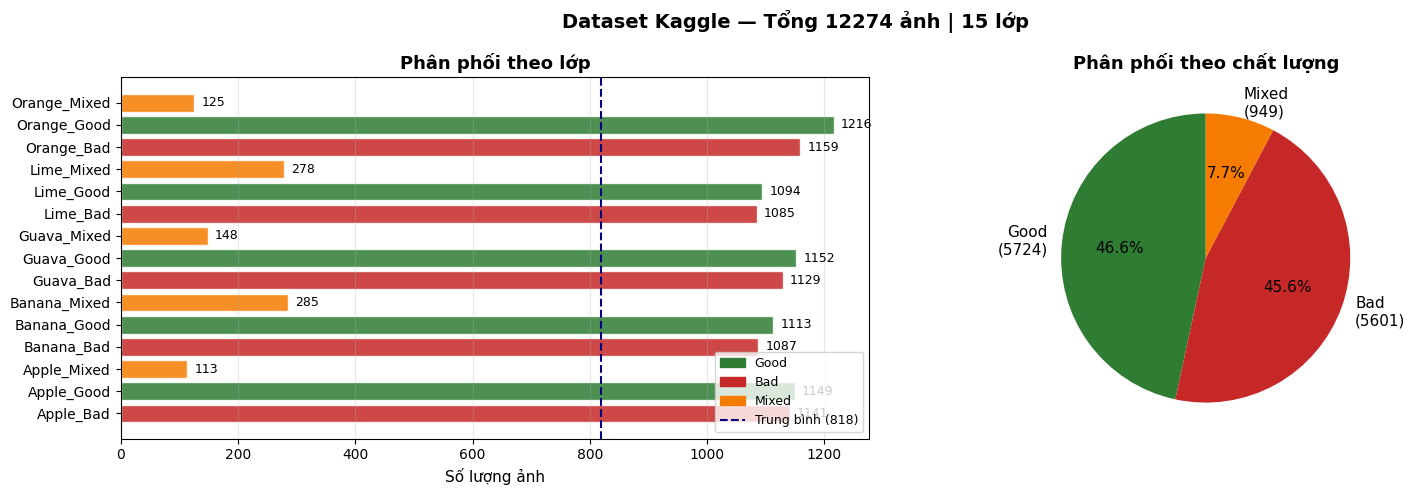

✅ Biểu đồ lưu: results/01_dataset_distribution.png


In [4]:
# ── Visualize phân phối dataset ───────────────────────────────────────────────
if class_to_paths:
    classes = sorted(class_to_paths.keys())
    counts  = [len(class_to_paths[c]) for c in classes]

    # Màu theo chất lượng
    bar_colors = []
    for c in classes:
        quality = c.split('_')[1]   # Good / Bad / Mixed
        bar_colors.append(QUALITY_COLORS.get(quality, '#888888'))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Bar chart theo lớp
    bars = axes[0].barh(classes, counts, color=bar_colors, alpha=0.85, edgecolor='white')
    for bar, n in zip(bars, counts):
        axes[0].text(bar.get_width() + max(counts)*0.01, bar.get_y() + bar.get_height()/2,
                     str(n), va='center', fontsize=9)
    axes[0].set_xlabel('Số lượng ảnh', fontsize=11)
    axes[0].set_title('Phân phối theo lớp', fontsize=13, fontweight='bold')
    axes[0].axvline(total/len(classes), color='navy', ls='--', lw=1.5,
                    label=f'Trung bình ({total//len(classes)})')
    axes[0].legend(fontsize=9)
    axes[0].grid(axis='x', alpha=0.3)

    # Pie chart theo chất lượng
    quality_counts = defaultdict(int)
    for cls, paths in class_to_paths.items():
        q = cls.split('_')[1]
        quality_counts[q] += len(paths)
    qlabels = list(quality_counts.keys())
    qvals   = [quality_counts[q] for q in qlabels]
    qcolors = [QUALITY_COLORS[q] for q in qlabels]
    axes[1].pie(qvals, labels=[f'{q}\n({v})' for q,v in zip(qlabels,qvals)],
                colors=qcolors, autopct='%1.1f%%', startangle=90,
                textprops={'fontsize':11})
    axes[1].set_title('Phân phối theo chất lượng', fontsize=13, fontweight='bold')

    # Legend chất lượng
    patches = [mpatches.Patch(color=v, label=k) for k,v in QUALITY_COLORS.items()]
    axes[0].legend(handles=patches + [axes[0].lines[0]], fontsize=9, loc='lower right')

    plt.suptitle(f'Dataset Kaggle — Tổng {total} ảnh | {len(classes)} lớp',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    os.makedirs('./results', exist_ok=True)
    plt.savefig('./results/01_dataset_distribution.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('✅ Biểu đồ lưu: results/01_dataset_distribution.png')

## Ô 3 — Hiển thị ảnh mẫu từng lớp

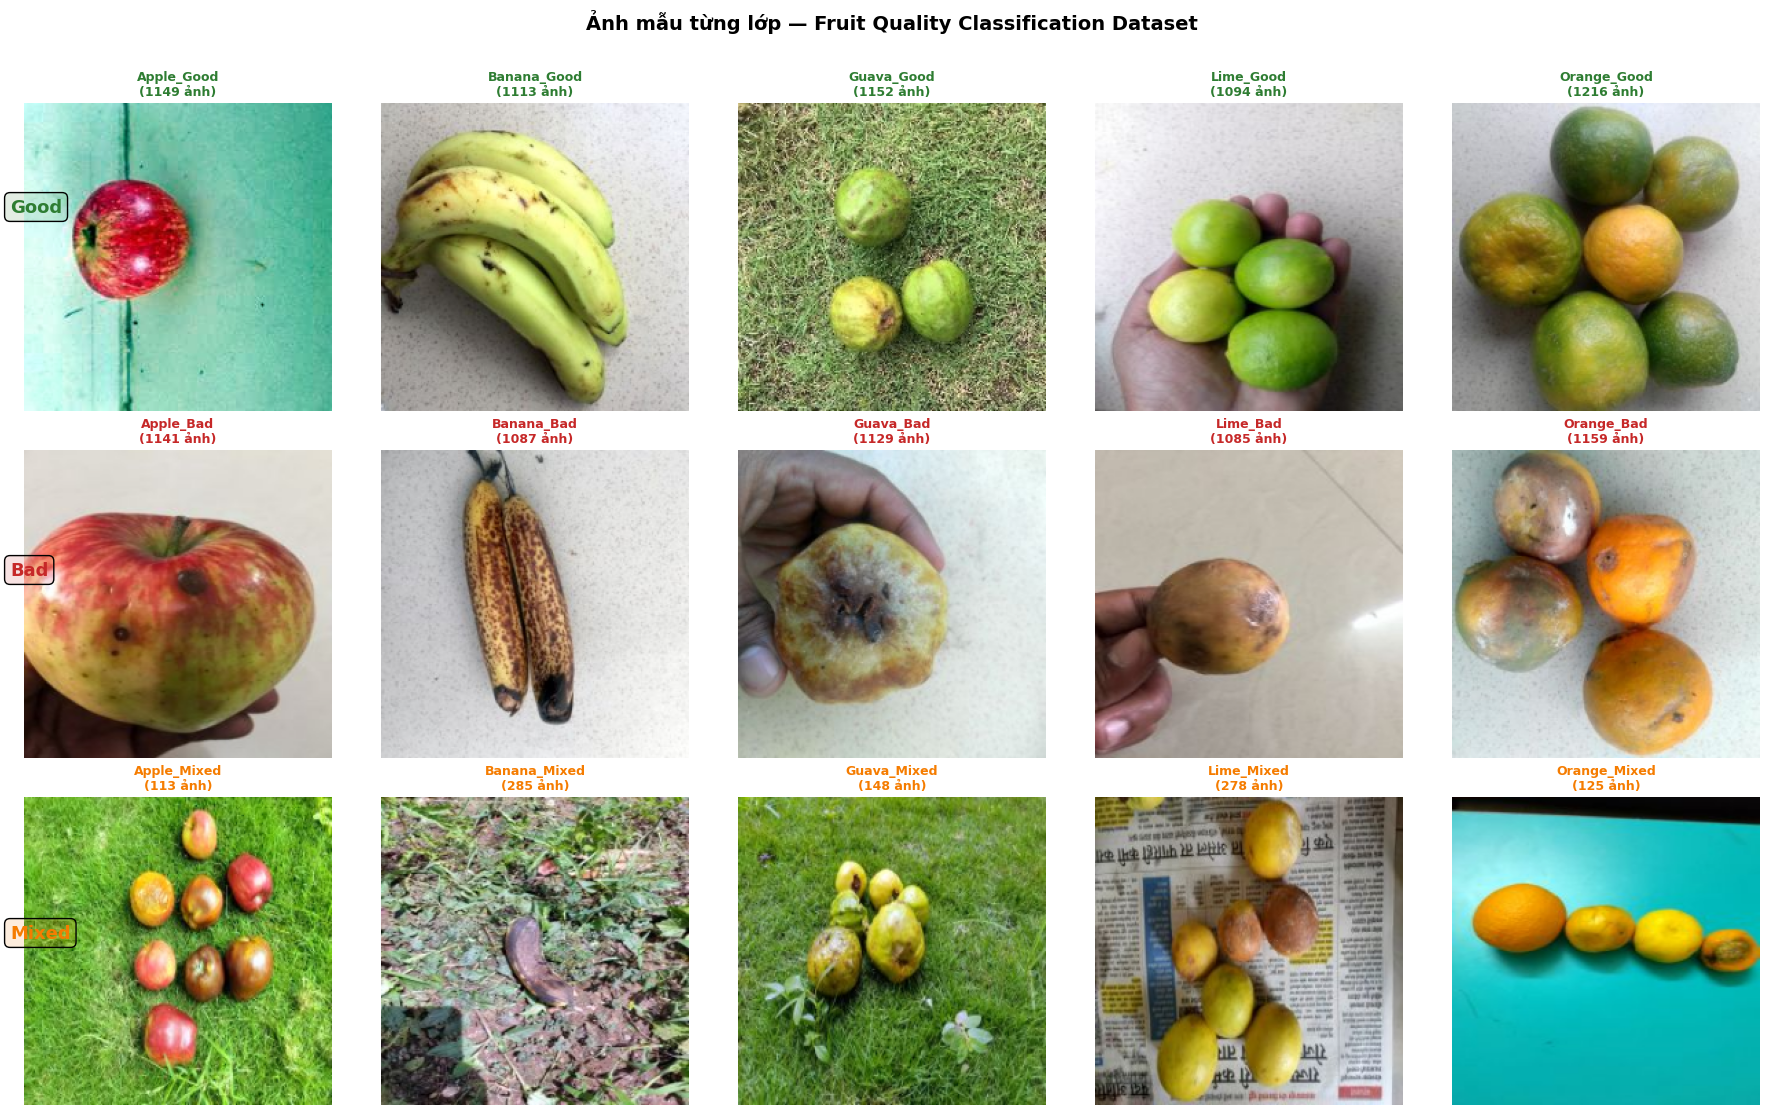

✅ Hình lưu: results/01_sample_images.png


In [5]:
# Hiển thị 1 ảnh mẫu cho từng lớp (3 hàng × 5 cột = 15 lớp)
classes_sorted = sorted(class_to_paths.keys())
n_classes      = len(classes_sorted)

# Nhóm theo chất lượng: Good / Bad / Mixed
groups = {
    'Good':  [c for c in classes_sorted if 'Good'  in c],
    'Bad':   [c for c in classes_sorted if 'Bad'   in c],
    'Mixed': [c for c in classes_sorted if 'Mixed' in c],
}

fig, axes = plt.subplots(3, 5, figsize=(18, 11))

for row_i, (quality, cls_list) in enumerate(groups.items()):
    for col_i in range(5):
        ax = axes[row_i][col_i]
        if col_i < len(cls_list):
            cls   = cls_list[col_i]
            paths = class_to_paths.get(cls, [])
            if paths:
                img = cv2.imread(random.choice(paths))
                img = cv2.resize(img, (224, 224))
                ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                fruit = cls.split('_')[0]
                ax.set_title(
                    f'{cls}\n({len(paths)} ảnh)',
                    fontsize=9, fontweight='bold',
                    color=QUALITY_COLORS[quality]
                )
            else:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                        transform=ax.transAxes, color='red')
        else:
            ax.set_facecolor('#f5f5f5')
        ax.axis('off')

# Row labels
for row_i, quality in enumerate(groups.keys()):
    fig.text(0.01, 0.83 - row_i*0.33, quality,
             va='center', ha='left', fontsize=13, fontweight='bold',
             color=QUALITY_COLORS[quality],
             bbox=dict(boxstyle='round,pad=0.3', facecolor=QUALITY_COLORS[quality]+'22'))

plt.suptitle('Ảnh mẫu từng lớp — Fruit Quality Classification Dataset',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('./results/01_sample_images.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Hình lưu: results/01_sample_images.png')

## Ô 4 — Chia train / valid / test và sao chép ảnh

In [6]:
def split_and_copy(class_to_paths, dataset_dir,
                   train_r=TRAIN_RATIO, valid_r=VALID_RATIO,
                   seed=RANDOM_STATE):
    """
    Chia mỗi lớp theo tỷ lệ train/valid/test (stratified),
    sao chép ảnh vào cấu trúc thư mục chuẩn.

    Cấu trúc đầu ra:
        dataset/
        ├── train/<ClassName>/<img>
        ├── valid/<ClassName>/<img>
        └── test/<ClassName>/<img>

    Returns:
        split_stats: dict {split: {class: count}}
    """
    random.seed(seed)
    test_r = 1.0 - train_r - valid_r

    split_stats = {s: defaultdict(int) for s in ['train','valid','test']}

    for cls_name, paths in tqdm(class_to_paths.items(), desc='Splitting classes'):
        shuffled = paths.copy()
        random.shuffle(shuffled)

        n      = len(shuffled)
        n_tr   = int(n * train_r)
        n_val  = int(n * valid_r)
        # test lấy phần còn lại (tránh mất ảnh do làm tròn)
        splits_data = {
            'train': shuffled[:n_tr],
            'valid': shuffled[n_tr:n_tr + n_val],
            'test':  shuffled[n_tr + n_val:],
        }

        for split_name, img_list in splits_data.items():
            dest_dir = os.path.join(dataset_dir, split_name, cls_name)
            os.makedirs(dest_dir, exist_ok=True)

            for src_path in img_list:
                fname    = os.path.basename(src_path)
                dst_path = os.path.join(dest_dir, fname)
                # Tránh ghi đè nếu tên trùng
                if os.path.exists(dst_path):
                    base, ext = os.path.splitext(fname)
                    dst_path  = os.path.join(dest_dir, f'{base}_{random.randint(1000,9999)}{ext}')
                shutil.copy2(src_path, dst_path)
                split_stats[split_name][cls_name] += 1

    return split_stats


# ── Chạy chia dataset ─────────────────────────────────────────────────────────
print(f'📂 Đang chia dataset vào: {os.path.abspath(DATASET_DIR)}')
print(f'   Train: {TRAIN_RATIO*100:.0f}%  |  Valid: {VALID_RATIO*100:.0f}%  |  Test: {TEST_RATIO*100:.0f}%')
print()

split_stats = split_and_copy(class_to_paths, DATASET_DIR)

print('\n✅ Chia dataset hoàn tất!')

📂 Đang chia dataset vào: d:\Workspace\fruit-quality-classification-cv\dataset
   Train: 70%  |  Valid: 15%  |  Test: 15%



Splitting classes:   0%|          | 0/15 [00:00<?, ?it/s]


✅ Chia dataset hoàn tất!


In [7]:
# ── In bảng thống kê split ────────────────────────────────────────────────────
classes_sorted = sorted(class_to_paths.keys())

print(f'\n{"─"*65}')
print(f'  {"Lớp":<22} {"Train":>8} {"Valid":>8} {"Test":>8} {"Tổng":>8}')
print(f'{"─"*65}')
grand = {'train':0,'valid':0,'test':0}
for cls in classes_sorted:
    tr  = split_stats['train'][cls]
    val = split_stats['valid'][cls]
    te  = split_stats['test'][cls]
    tot = tr + val + te
    grand['train'] += tr; grand['valid'] += val; grand['test'] += te
    print(f'  {cls:<22} {tr:>8} {val:>8} {te:>8} {tot:>8}')
print(f'{"─"*65}')
total_all = grand['train']+grand['valid']+grand['test']
print(f'  {"TỔNG":<22} {grand["train"]:>8} {grand["valid"]:>8} {grand["test"]:>8} {total_all:>8}')
print(f'  {"Tỷ lệ":<22} {grand["train"]/total_all*100:>7.1f}% {grand["valid"]/total_all*100:>7.1f}% {grand["test"]/total_all*100:>7.1f}%')
print(f'{"─"*65}')


─────────────────────────────────────────────────────────────────
  Lớp                       Train    Valid     Test     Tổng
─────────────────────────────────────────────────────────────────
  Apple_Bad                   798      171      172     1141
  Apple_Good                  804      172      173     1149
  Apple_Mixed                  79       16       18      113
  Banana_Bad                  760      163      164     1087
  Banana_Good                 779      166      168     1113
  Banana_Mixed                199       42       44      285
  Guava_Bad                   790      169      170     1129
  Guava_Good                  806      172      174     1152
  Guava_Mixed                 103       22       23      148
  Lime_Bad                    759      162      164     1085
  Lime_Good                   765      164      165     1094
  Lime_Mixed                  194       41       43      278
  Orange_Bad                  811      173      175     1159
  Orange_Good

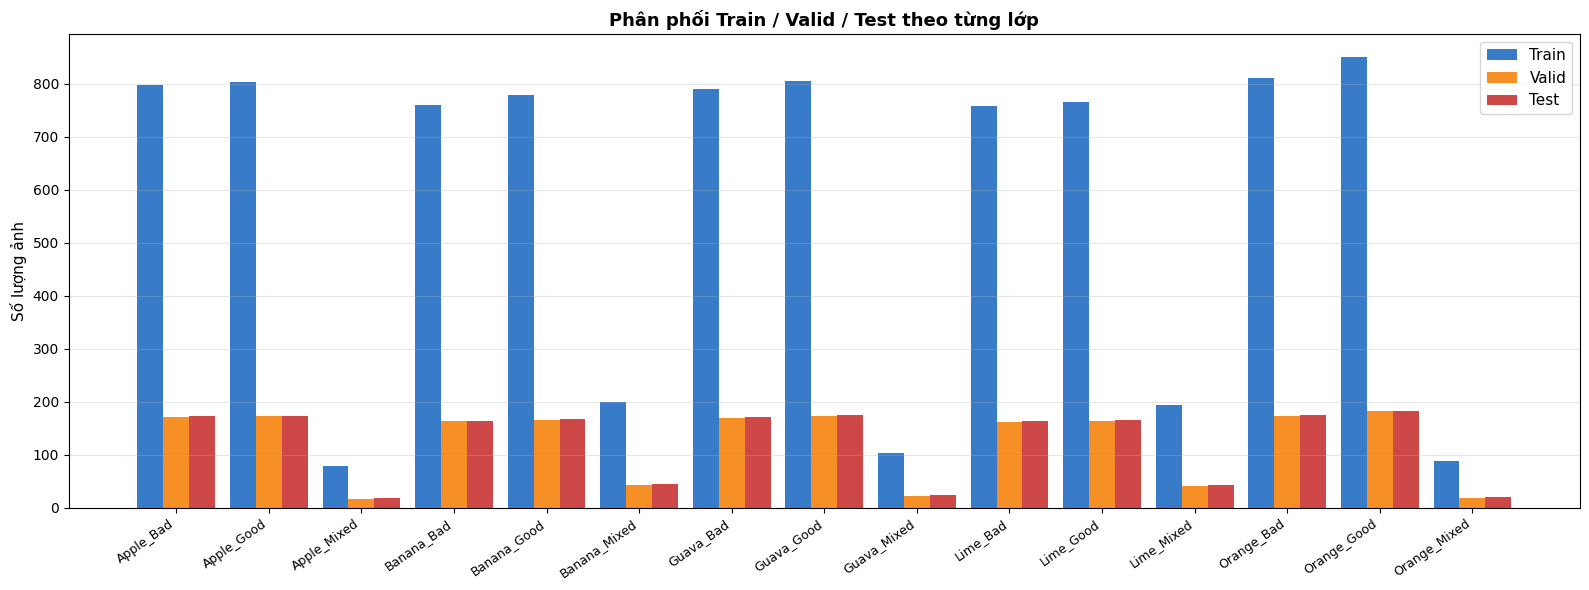

✅ Biểu đồ lưu: results/01_split_distribution.png


In [8]:
# ── Visualize phân phối train/valid/test ──────────────────────────────────────
classes_sorted = sorted(class_to_paths.keys())
x = np.arange(len(classes_sorted))
w = 0.28

tr_vals  = [split_stats['train'][c] for c in classes_sorted]
val_vals = [split_stats['valid'][c] for c in classes_sorted]
te_vals  = [split_stats['test'][c]  for c in classes_sorted]

fig, ax = plt.subplots(figsize=(16, 6))
b1 = ax.bar(x - w, tr_vals,  w, label='Train', color='#1565C0', alpha=0.85)
b2 = ax.bar(x,     val_vals, w, label='Valid',  color='#F57C00', alpha=0.85)
b3 = ax.bar(x + w, te_vals,  w, label='Test',   color='#C62828', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(classes_sorted, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Số lượng ảnh', fontsize=11)
ax.set_title('Phân phối Train / Valid / Test theo từng lớp',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('./results/01_split_distribution.png', dpi=130, bbox_inches='tight')
plt.show()
print('✅ Biểu đồ lưu: results/01_split_distribution.png')

## Ô 5 — Xác nhận cấu trúc thư mục đầu ra

In [9]:
def verify_dataset_structure(dataset_dir):
    """Kiểm tra cấu trúc thư mục và đếm ảnh trong từng split/class."""
    print(f'\n📁 Xác nhận cấu trúc: {os.path.abspath(dataset_dir)}')
    print()
    all_ok = True

    for split in ['train', 'valid', 'test']:
        split_dir = os.path.join(dataset_dir, split)
        if not os.path.exists(split_dir):
            print(f'  ❌ Thiếu thư mục: {split}/')
            all_ok = False
            continue

        class_dirs = sorted(os.listdir(split_dir))
        n_imgs     = sum(
            len(glob.glob(os.path.join(split_dir, c, '*')))
            for c in class_dirs
        )
        print(f'  ✅ {split:6s}/ → {len(class_dirs):2d} lớp | {n_imgs:5d} ảnh')

        for cls in class_dirs:
            n = len(glob.glob(os.path.join(split_dir, cls, '*')))
            print(f'       ├── {cls:<22} {n:>5} ảnh')

    return all_ok

ok = verify_dataset_structure(DATASET_DIR)
print()
if ok:
    print('🎉 Dataset đã sẵn sàng để dùng cho notebook 02_FruitQuality_Pipeline.ipynb!')
else:
    print('⚠️  Có lỗi — kiểm tra lại KAGGLE_ROOT và chạy lại Ô 4.')


📁 Xác nhận cấu trúc: d:\Workspace\fruit-quality-classification-cv\dataset

  ✅ train / → 15 lớp |  8585 ảnh
       ├── Apple_Bad                798 ảnh
       ├── Apple_Good               804 ảnh
       ├── Apple_Mixed               79 ảnh
       ├── Banana_Bad               760 ảnh
       ├── Banana_Good              779 ảnh
       ├── Banana_Mixed             199 ảnh
       ├── Guava_Bad                790 ảnh
       ├── Guava_Good               806 ảnh
       ├── Guava_Mixed              103 ảnh
       ├── Lime_Bad                 759 ảnh
       ├── Lime_Good                765 ảnh
       ├── Lime_Mixed               194 ảnh
       ├── Orange_Bad               811 ảnh
       ├── Orange_Good              851 ảnh
       ├── Orange_Mixed              87 ảnh
  ✅ valid / → 15 lớp |  1833 ảnh
       ├── Apple_Bad                171 ảnh
       ├── Apple_Good               172 ảnh
       ├── Apple_Mixed               16 ảnh
       ├── Banana_Bad               163 ảnh
       ├── Banana_Good

In [10]:
# ── In cấu trúc thư mục dạng tree ────────────────────────────────────────────
print('📂 Cấu trúc thư mục dataset/')
print('dataset/')
for split in ['train', 'valid', 'test']:
    split_dir  = os.path.join(DATASET_DIR, split)
    class_dirs = sorted(os.listdir(split_dir)) if os.path.exists(split_dir) else []
    total_imgs = sum(len(glob.glob(os.path.join(split_dir,c,'*'))) for c in class_dirs)
    is_last    = (split == 'test')
    prefix     = '└──' if is_last else '├──'
    print(f'{prefix} {split}/  ({total_imgs} ảnh)')
    for i, cls in enumerate(class_dirs):
        n        = len(glob.glob(os.path.join(split_dir,cls,'*')))
        bar_pre  = '    ' if is_last else '│   '
        is_last_cls = (i == len(class_dirs)-1)
        sym      = '└──' if is_last_cls else '├──'
        print(f'{bar_pre}{sym} {cls}/  ({n})')

print(f'\n✅ Hoàn tất! Tiếp tục mở notebook: 02_FruitQuality_Pipeline.ipynb')

📂 Cấu trúc thư mục dataset/
dataset/
├── train/  (8585 ảnh)
│   ├── Apple_Bad/  (798)
│   ├── Apple_Good/  (804)
│   ├── Apple_Mixed/  (79)
│   ├── Banana_Bad/  (760)
│   ├── Banana_Good/  (779)
│   ├── Banana_Mixed/  (199)
│   ├── Guava_Bad/  (790)
│   ├── Guava_Good/  (806)
│   ├── Guava_Mixed/  (103)
│   ├── Lime_Bad/  (759)
│   ├── Lime_Good/  (765)
│   ├── Lime_Mixed/  (194)
│   ├── Orange_Bad/  (811)
│   ├── Orange_Good/  (851)
│   └── Orange_Mixed/  (87)
├── valid/  (1833 ảnh)
│   ├── Apple_Bad/  (171)
│   ├── Apple_Good/  (172)
│   ├── Apple_Mixed/  (16)
│   ├── Banana_Bad/  (163)
│   ├── Banana_Good/  (166)
│   ├── Banana_Mixed/  (42)
│   ├── Guava_Bad/  (169)
│   ├── Guava_Good/  (172)
│   ├── Guava_Mixed/  (22)
│   ├── Lime_Bad/  (162)
│   ├── Lime_Good/  (164)
│   ├── Lime_Mixed/  (41)
│   ├── Orange_Bad/  (173)
│   ├── Orange_Good/  (182)
│   └── Orange_Mixed/  (18)
└── test/  (1856 ảnh)
    ├── Apple_Bad/  (172)
    ├── Apple_Good/  (173)
    ├── Apple_Mixed/  (18)
    ├─